### Laboratorio 1

**Grupo 16**

**Integrantes:**
Mateo Zambrano 202321531,
Nicolas Romero

### 1. Configuración y carga de datos

### 1.1 Importación de librerías

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

### 1.2 Constantes de reproducibilidad

In [4]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
OBJETIVO = "temp_max_manana"

### 1.3 Carga de datos

In [5]:
DATA_DIR = Path("data")
RUTA_TRAIN = DATA_DIR / "datos Lab 1.csv"
RUTA_SIN_ETIQUETA = DATA_DIR / "Datos Test Lab 1.csv"
RUTA_DICCIONARIO = DATA_DIR / "Diccionario de datos.xlsx"

datos = pd.read_csv(RUTA_TRAIN)
sin_etuiqueta = pd.read_csv(RUTA_SIN_ETIQUETA)
diccionario = pd.read_excel(RUTA_DICCIONARIO)

print("Entrenamiento:", datos.shape)
print("No etiquetados: ", sin_etuiqueta.shape)
print("Columnas que están en train y no en el archivo sin etiquetar:", set(datos.columns) - set(sin_etuiqueta.columns))

diccionario

Entrenamiento: (2576, 27)
No etiquetados:  (364, 26)
Columnas que están en train y no en el archivo sin etiquetar: {'temp_max_manana'}


,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


### 2. Exploración de datos

### 2.1 Estructura general/exploración inicial

In [6]:
display(datos.head())
datos.info()
datos.shape

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

(2576, 27)

### 2.2 Observaciones

**fecha:** Se puede observar redundancias con las columnas **anio**, **dia_del_anio** y **mes**. En el caso de no coincidir, puede significar que algunos datos están corruptos, pues tienen información contradictoria. También se puede justificar un cambio de tipo de dato a DateTime64 con el fin de facilitar operaciones entre fechas.

**registros_del_dia:** Como número que representa la cantidad de mediciones de 10 minutos por día, es más justificable verlo como un int64 más que un float64.

**anio:** Redundante por la columna **fecha**. Este dato podría convertirse a int64 sin inconvenientes.

**dia_del_anio:** Redundante por la columna **fecha**. Este dato podría convertirse a int64 sin inconvenientes.

**estacion_anio:** Presenta datos que no corresponden a ninguna estación, como por ejemplo la fila 4. Estos valores inválidos se podrían reemplazar por datos NaN. También presenta datos inconsistentes y datos escritos con mayúsculas, minúsculas, español o inglés.

**mes:** Redundante por la columna **fecha**. Esta columna presenta datos escritos completamente en mayúsculas y otros datos en minúsculas, en inglés o en español.

**presion_media, min, max:** Son columnas que están correlacionadas, lo que puede afectar la interpretación de coeficientes.

**humedad_media, min, max:** Son columnas que están correlacionadas, lo que puede afectar la interpretación de coeficientes.

**viento_norte, viento_este, direccion_viento:** Son columnas que están correlacionadas, debido a que cada columna representa el componente de un mismo dato.

**sector_viento:** Debería tener 8 categorías (N, NE, E, SE, S, SO, O, NO) pero aparecen muchas más debido a variantes en mayúsculas, algunas en español o inglés en vez de la abreviatura, lo cual se podría considerar una inconsistencia.

**rafaga_min:** Presenta al menos un valor "centinela" (-9999), que representa un dato faltante codificado como número, por lo que debería convertirse a NaN antes alguna operación debido a que podría modificar la mediana o perjudicar la regresión lineal.

**humedad_media, humedad_min:** Se agrega esta observación aparte de **humedad_media, min, max** por su importancia: En estas columnas se observan 2 escalas mezcladas dentro de la misma columna, (una expresada como proporción 0-1 y otra como porcentaje 0%-100%). Esto es un problema de validez porque cada valor es válido, pero de forma separada. Se debería unificar a una sola escala.

### 2.3 Justificaciones

En esta sección se presentará la evidencia que sustenta las observaciones de la sección anterior, ordenadas siguiendo las cuatro dimensiones de calidad de datos (completitud, unicidad, consistencia, validez).

#### 2.3.1 Completitud

Mide si el dataset tiene toda la información esperada, o en otras palabras, que no falten datos.

In [7]:
(datos.isnull().sum()/datos.shape[0]).sort_values(ascending=False)

temp_max_manana      0.036879
viento_min           0.035326
estacion_anio        0.034161
mes                  0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
humedad_min          0.031056
viento_norte         0.031056
presion_desv         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
presion_min          0.028727
humedad_media        0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
presion_max          0.024845
viento_este          0.024845
humedad_desv         0.023680
dtype: float64

In [8]:
print("faltantes por año")
for anio in datos["anio"].dropna().unique():
   datos_anio = datos[datos["anio"] == anio]
   n_faltantes = datos_anio.isnull().sum().sum()
   print(f"{int(anio)}: {n_faltantes}")

faltantes por año
2009: 257
2010: 273
2011: 300
2012: 265
2013: 275
2014: 260
2015: 306


In [44]:
print("variable objetivo")
print(f"{OBJETIVO}: {datos[OBJETIVO].isna().sum()} faltantes ({datos[OBJETIVO].isna().sum()/len(datos)*100:.2f}%))")
print(f"  Distribución:")
print(datos[OBJETIVO].describe())

variable objetivo
temp_max_manana: 95 faltantes (3.69%))
  Distribución:
count    2481.000000
mean       13.863309
std         9.296199
min       -15.230000
25%         7.310000
50%        14.310000
75%        20.460000
max        63.050000
Name: temp_max_manana, dtype: float64


**Valores faltantes:** Todas las columnas presentan un porcentaje de datos faltantes de entre 2%-4%, lo que sugiere que no hay un patrón de ausencia. Como es un porcentaje bajo y disperso, se imputarán los valores con la mediana en lugar de eliminar las filas para poder minimizar la pérdida de datos para el modelo.

**temp_max_manana:** hay un 3.69% de datos faltantes para la variable objetivo, por lo cual no se pueden imputar aquellos datos, por lo que dichas filas serán eliminadas.

#### 2.3.2 Unicidad

Verifica que cada registro aparece exactamente 1 vez, por lo que se buscarán detectar filas idénticas y duplicados lógicos (misma llave de negocio con datos diferentes). En este caso, la llave de negocio es la fecha, por lo que cada día deberá aparecer una sola vez. 

In [9]:
#Filas identicas
print("Duplicados exactos:", datos.duplicated(keep=False).sum())

#Duplicados lógicos
fechas_repetidas = datos["fecha"].value_counts().loc[lambda x: x > 1]
print("Fechas que se repiten:", len(fechas_repetidas))

Duplicados exactos: 8
Fechas que se repiten: 18


In [39]:
print("registros_del_dia > 144:", (datos["registros_del_dia"] > 144).sum())

registros_del_dia > 144: 4


**Duplicados:** Se detectaron filas exactas, lo que corresponde a un error de carga y deben eliminarse. Además, existen registros con la misma fecha pero valore diferentes entre sí (duplicados lógicos). Como cada fila debería representar un día único, esto rerpesenta una inconsistencia. En este caso, se decidiría con cual copia quedarse, lo cual se puede decidir observando la columna **registros_del_dia**, pues el que más registros tenga representa más mediciones, por ende más datos. Cabe aclarar que hay 4 filas que contienen un número de registros del día inválido, por lo que se decidirá eliminar dichas filas. Se discutirá **registros_del_dia** en la sección de validez.

#### 2.3.3 Consistencia

Se verifica que los valores que representan el mismo concepto estén escritos de forma uniforme, es decir, que todos los datos que representan un mismo concepto se presenten de forma consistente y sin variaciones.

In [10]:
datos["estacion_anio"].value_counts(dropna=False)

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

In [11]:
datos["mes"].value_counts(dropna=False)

mes
May           127
August        125
July          123
January       120
March         118
             ... 
april          16
septiembre     16
junio          16
Jan            13
OCTOBER        13
Name: count, Length: 62, dtype: int64

In [12]:
datos["sector_viento"].value_counts(dropna=False)

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
NaN           71
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
South         19
ne            19
NORTHEAST     17
Sur           16
Noreste       12
o              8
SOUTH          8
NORTH          6
no             6
West           5
WEST           5
North          4
East           4
EAST           4
Sureste        3
Oeste          3
Noroeste       3
SOUTHEAST      3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64

**Inconsistencia:** Se pueden ver inconsistencias en los datos de estas 3 columnas. Se requiere normalizar los datos.

#### 2.3.4 Validez

Se verifica que los valores estén dentro del rango esperado según el diccionario de datos.

In [13]:
datos.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,2495.000000,2504.000000,2498.000000,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,7.647484,13.859643,2.988370,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,6.785897,76.009623,27.846414,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,0.000000,0.000000,-1386.273300,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,3.370000,0.757000,2.511875,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,5.051746,1.054850,3.228800,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,9.630000,1.571550,4.264600,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,45.108000,3319.030100,11.465200,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


Ahora se verificaran datos centinelas, errores de magnitud y escalas mezcladas:

In [14]:
for col in datos.select_dtypes("number").columns:
    n = datos[col].isin([-9999, -999, 9999]).sum()
    if n > 0:
        print(f"{col}: {n} valores centinela")

rafaga_min: 1 valores centinela


humedad_media <= 1: 776
humedad_media > 1: 1726
humedad_media > 100: 0


<Axes: >

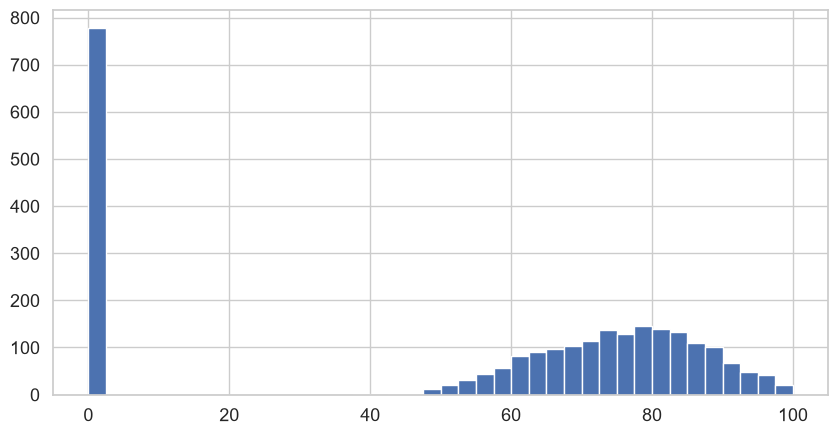

In [33]:
print("humedad_media <= 1:", (datos["humedad_media"] <= 1).sum())
print("humedad_media > 1:", (datos["humedad_media"] > 1).sum())
print("humedad_media > 100:", (datos["humedad_media"] > 100).sum())

datos["humedad_media"].hist(bins=40)

humedad_min <= 1: 621
humedad_min > 1: 1875
humedad_min > 100: 23


<Axes: >

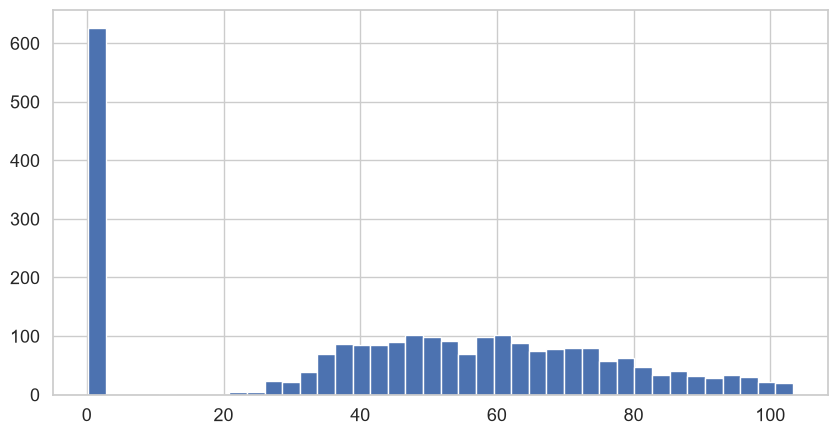

In [32]:
print("humedad_min <= 1:", (datos["humedad_min"] <= 1).sum())
print("humedad_min > 1:", (datos["humedad_min"] > 1).sum())
print("humedad_min > 100:", (datos["humedad_min"] > 100).sum())

datos["humedad_min"].hist(bins=40)

humedad_max <= 1: 0
humedad_max > 1: 2490
humedad_max > 100: 0


<Axes: >

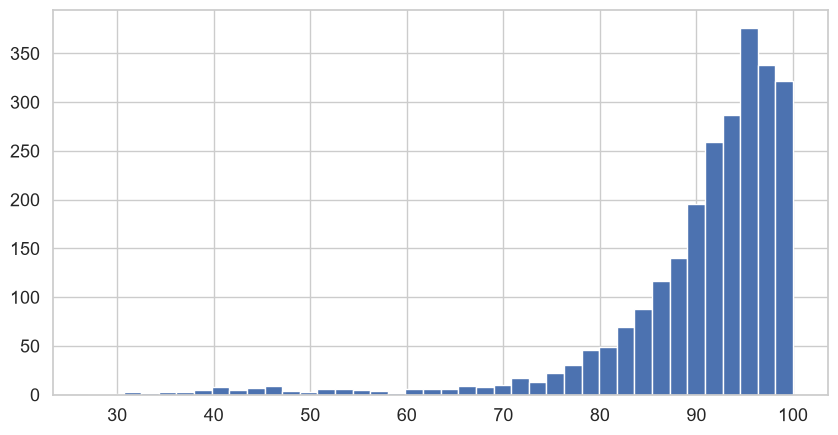

In [30]:
print("humedad_max <= 1:", (datos["humedad_max"] <= 1).sum())
print("humedad_max > 1:", (datos["humedad_max"] > 1).sum())
print("humedad_max > 100:", (datos["humedad_max"] > 100).sum())

datos["humedad_max"].hist(bins=40)

In [40]:
print("registros_del_dia > 144:", (datos["registros_del_dia"] > 144).sum())

registros_del_dia > 144: 4


**Validez:** Como se puede observar, hay evidencias de que **humedad_media** esta usando 2 escalas al mismo tiempo. Una de ellas está puesta en porcentaje y la otra está convertida a decimal. Debido a la descripción del diccionario de datos, se decidirá por convertir los valores decimales a porcentajes para arreglar el problema de validez de los datos. Lo mismo ocurre con **humedad_min** salvo que contiene un problema extra, y es que hay valores por encima de 100 y, debido a esto, para no perder otros datos de la fila por eliminarla, se cambiarán los valores por encima de 100 a NaN. **humedad_max** está limpio.

En cuanto a la columna **registros_del_dia**, se decidirá eliminar las 4 filas que registran un número más alto que la cantidad máxima de registros, pues se estima que podrían perturbar el análisis correcto.

#### 2.3.5 Relaciones entre variables

Se verifica la multicolinealidad y estacionalidad de las variables.

Se empieza primero por verificar la multicolinealidad de la variable de componentes de viento. Además, se confirma la validez de otras variables numéricas como la presion, humedad, viento y rafaga.

In [48]:
bloques = {
    "presion": ["presion_media", "presion_max", "presion_min"],
    "humedad": ["humedad_media", "humedad_max", "humedad_min"],
    "viento": ["viento_media", "viento_max", "viento_min"],
    "rafaga": ["rafaga_media", "rafaga_max", "rafaga_min"],
    "componentes_viento": ["viento_norte", "viento_este", "direccion_viento"],
}

for item, cols in bloques.items():
    cols_existentes = [c for c in cols if c in datos.columns]
    print(f"\n{item}:")
    print(datos[cols_existentes].corr(numeric_only=True).round(3))


presion:
               presion_media  presion_max  presion_min
presion_media          1.000        0.034       -0.013
presion_max            0.034        1.000        0.834
presion_min           -0.013        0.834        1.000

humedad:
               humedad_media  humedad_max  humedad_min
humedad_media          1.000        0.053        0.812
humedad_max            0.053        1.000       -0.100
humedad_min            0.812       -0.100        1.000

viento:
              viento_media  viento_max  viento_min
viento_media         1.000       0.846       0.299
viento_max           0.846       1.000      -0.036
viento_min           0.299      -0.036       1.000

rafaga:
              rafaga_media  rafaga_max  rafaga_min
rafaga_media         1.000       0.024       0.999
rafaga_max           0.024       1.000      -0.014
rafaga_min           0.999      -0.014       1.000

componentes_viento:
                  viento_norte  viento_este  direccion_viento
viento_norte             1.000 

In [ ]:
datos.plot.scatter(x="dia_del_anio", y=OBJETIVO, alpha=0.5, s = 10, title = "Temperatura max vs dia del año")
plt.xlabel("Día del año")
plt.ylabel("Temperatura máxima (°C)")
plt.show()
